In [ ]:
from analyzer import * 
from utils.corr import *  
from utils.plot_corr import *   
from utils.plots import get_family, parse_size 
import seaborn as sns 
sns.set_style('whitegrid') 

mm = MMStarResults()
# answers_pivot = mm.combine_mh(model_acc=mm.model_mc) 
md = mm.model_blind 
pids = mm.human.participant_id.unique()    
md.finetuned.unique()  , md.model.unique() 

/home/work/.anaconda/envs/privacyovod_new_copy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# MMStar 

In [ ]:
n_boot = 0
metrics = 'correct' 
human_acc = mm.human.pivot(
    index="question_id",
    columns="participant_id",
    values=metrics
)
test_model = mm.test_model
test_model = test_model[test_model['condition'] == ''] 
model_correct = test_model[test_model['condition'] == ''].groupby(['model', 'finetuned'])['correct'].mean().reset_index()   
model_correct = model_correct[~model_correct['model'].isin(['Qwen3 (4B)', 'Qwen3 (8B)'])] 
pcorr = pd.merge(model_corr, model_correct, how='left', on=['model', 'finetuned'])    
# Remove (n=15) from finetuned column values in pcorr DataFrame 
pcorr['finetuned'] = pcorr['finetuned'].str.replace(r"\s*\(n=15\)", "", regex=True)
pcorr.finetuned.unique()

array(['Pretrained', 'SFT-Blind MMStar', 'JS-Blind MMStar'], dtype=object)

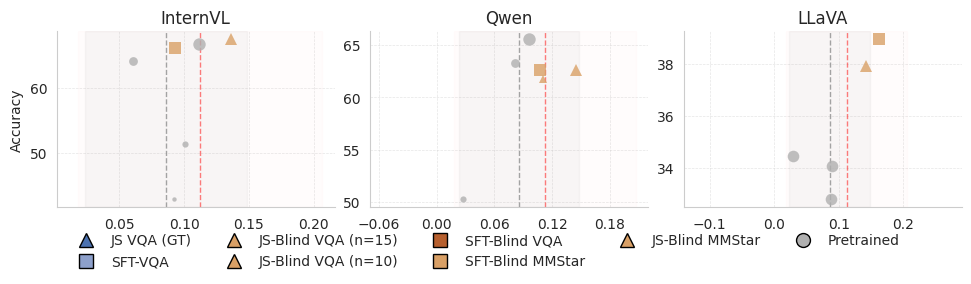

In [ ]:
qwen = np.mean([0.078375, 0.093314])
qwen_sd = np.sqrt((0.068510**2 + 0.048663**2) / 2)  

nrows, ncols = 1, 3
max_panels = nrows * ncols
fig, axes = plt.subplots(
    nrows, ncols, 
    figsize=(3.2 * ncols, 2.3 * nrows),
    constrained_layout=True,
    # sharey=True,  # Share y axis
    # sharex=True, # if xshared else False,
    squeeze=False
)
ylabel, xlabel = "Accuracy", r"${\rho}$" 
axes_flat = axes.flatten() 
for idx, fam in enumerate(model_corr.family.unique()) : 
    ax = axes_flat[idx] 
    ax.set_title(fam, fontsize=12)
    if idx == 0 : 
        ax.set_ylabel(ylabel, fontsize=10) 
    ax = plot_family_scatter(
        pcorr[pcorr['family'] == fam], ax, value_col='correct', mu=mean_corr, sd=std_corr 
    ) 
    # ax.set_xlim(0, 0.25)
    ci_low, ci_high = get_ci(qwen, qwen_sd, len(test_subjects)) 
    ax.axvspan(ci_low, ci_high, alpha=0.05, color='gray', zorder=1)
    ax.axvline(qwen, color='gray', linestyle='--', linewidth=1, alpha=0.7, zorder=1, label='Qwen')
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontsize(10)

regime_handles = [
    Line2D(
        [0], [0],
        marker=regime_markers.get(f, "o"),
        color='w',
        markerfacecolor=regime_colors[f],
        markeredgecolor='black',
        markersize=10,
        linestyle="",
        label=f
    )
    for f in regime_colors
]
legend_handles = regime_handles
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=5,
    bbox_to_anchor=(0.5, -0.3),  # adjust as needed for space below
    frameon=False,
    fontsize=10,
)

plt.show() 

# VQA 

In [374]:
vv = VQAResults()   
human_vqa = vv.human.drop_duplicates(subset=['question_id', 'participant_id']) 
# get_agreements(human_vqa, model_vqa, metrics="correct", n_boot=200) 
model_vqa = vv.model  # only the blind condition 
test_vqa = vv.test_model 
# human_vqa[human_vqa['question_id'] == 524577006 ].iloc[12][['processed_ans', 'correct', 'gt_answers']]  
model_vqa = vv.model
model_vqa = model_vqa[model_vqa['trained_dataset'] != 'MMStar']
model_vqa_pretrained = model_vqa[model_vqa['finetuned'] == 'Pretrained'] 

   Loading VQA annotations from /home/work/yuna/data/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
14 6
[]
[]


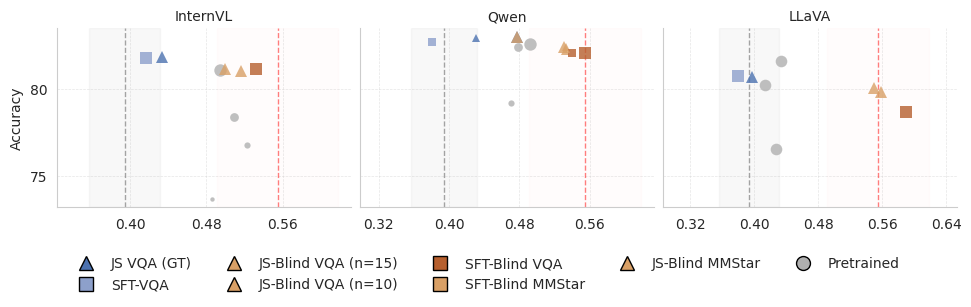

In [ ]:
import pandas as pd 

mm.get_corr(human_vqa, model_vqa, test_subjects)
plot_families_corr(llm_mean= np.mean([0.382820, 0.405282]),
                   llm_sd=np.sqrt((0.038112**2 + 0.033457**2) / 2), 
                   mean_corr, std_corr) 

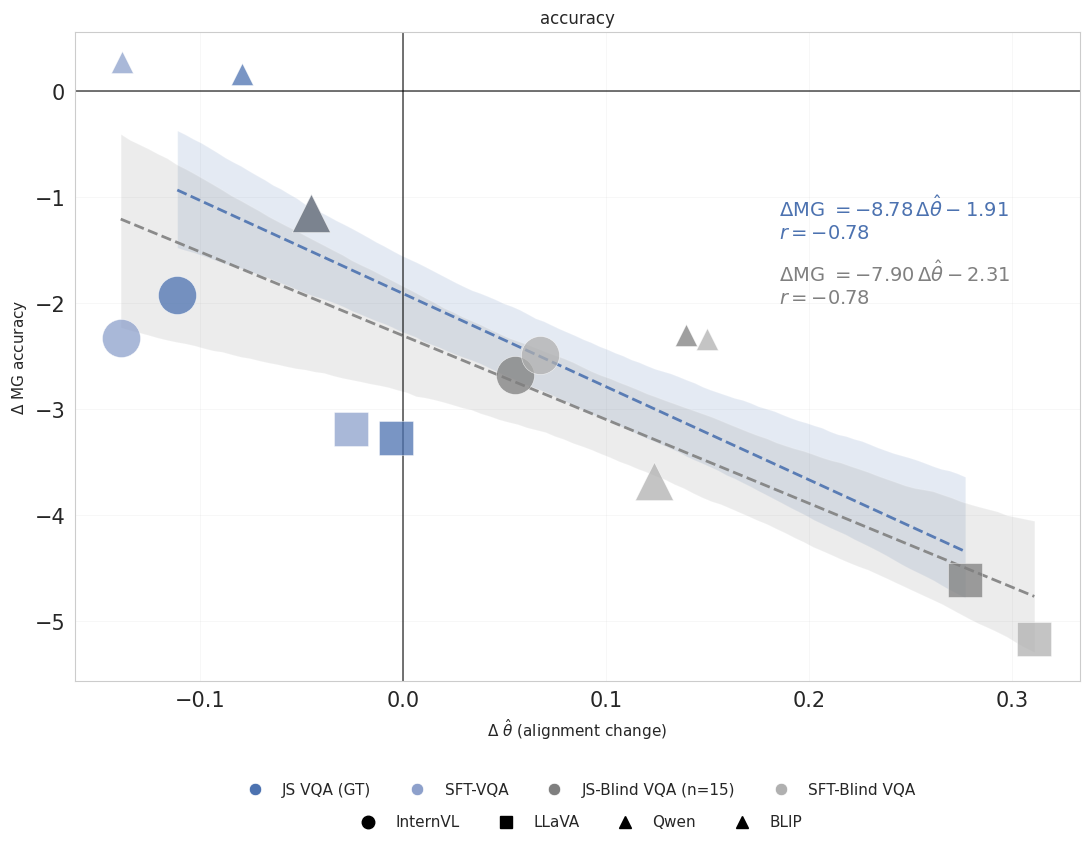

In [655]:
x_col = "theta_hat"
y_col = "MG_acc" 
delta_df = get_delta_df(pcorr[pcorr['dataset'] == 'VQA'])

scatterplot_delta_alignment_vs_mg(
    delta_df,
    title = 'accuracy',
    regression_stats = get_stats(delta_df), 
    EQ_POS= {
    "JS":  (0.7, 0.75),
    "SFT": (0.7, 0.65),
    }, 
    colors= regime_colors,          # keyed by finetuned regime
    markers= family_markers ,
    figsize=(11,8) ) 